In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pycocotools", "-q"])

In [1]:
import os, sys, random, time
from pathlib import Path
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from pycocotools.coco import COCO
from tqdm.auto import tqdm

UTILS_DIR = str(Path(".").resolve() / "src")
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from engine           import train, evaluate, get_all_predictions
from utils            import set_seeds, get_device, device_info, save_model, count_parameters, print_train_time
from helper_functions import plot_loss_curves, confusion_matrix
from predictions      import pred_and_plot_image, predict_top_k
from coco_dataset     import COCOClassificationDataset

device_info()
DEVICE = get_device()
print(f"device: {DEVICE}")

PyTorch version : 2.10.0
CUDA available  : False
MPS available   : True
Best device     : mps
device: mps


In [2]:
COCO_ROOT  = Path.home() / "Desktop" / "mit club" / "coco" / "coco2014"
TRAIN_IMGS = COCO_ROOT / "images/train2014"
VAL_IMGS   = COCO_ROOT / "images/val2014"
TRAIN_ANN  = COCO_ROOT / "annotations/instances_train2014.json"
VAL_ANN    = COCO_ROOT / "annotations/instances_val2014.json"

for p in [TRAIN_IMGS, VAL_IMGS, TRAIN_ANN, VAL_ANN]:
    assert p.exists(), f"not found: {p}"

NUM_CLS    = 5
CLS_NAMES  = ["person", "car", "dog", "cat", "bicycle"]
assert len(CLS_NAMES) == NUM_CLS

IMG_SZ     = 128    # 224 for better accuracy
BATCH_SZ   = 32
EPOCHS_EXP = 5      # 20% experiment
EPOCHS     = 15     # full training
LR         = 1e-3
SEED       = 42
EXP_FRAC   = 0.20
MAX_CLS    = None   

NUM_WORKERS = os.cpu_count()   
PIN_MEMORY  = False

In [3]:
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SZ, IMG_SZ)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SZ, IMG_SZ)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("loading train...")
train_ds = COCOClassificationDataset(TRAIN_ANN, TRAIN_IMGS, CLS_NAMES, train_tfm, MAX_CLS)
print("loading val...")
val_ds   = COCOClassificationDataset(VAL_ANN,   VAL_IMGS,   CLS_NAMES, val_tfm,   MAX_CLS)

loading train...
loading annotations into memory...
Done (t=2.83s)
creating index...
index created!
[dataset] 51,573 images | 5 classes
loading val...
loading annotations into memory...
Done (t=1.54s)
creating index...
index created!
[dataset] 25,066 images | 5 classes


In [4]:
def class_dist(ds):
    c = Counter(s[1] for s in ds.samples)
    for i, n in enumerate(CLS_NAMES):
        print(f"  {n:15s}: {c.get(i, 0):>6,}")

print("train:"); class_dist(train_ds)
print("val:");   class_dist(val_ds)

train:
  person         : 41,288
  car            :  4,837
  dog            :  2,204
  cat            :  2,556
  bicycle        :    688
val:
  person         : 19,786
  car            :  2,433
  dog            :  1,126
  cat            :  1,358
  bicycle        :    363


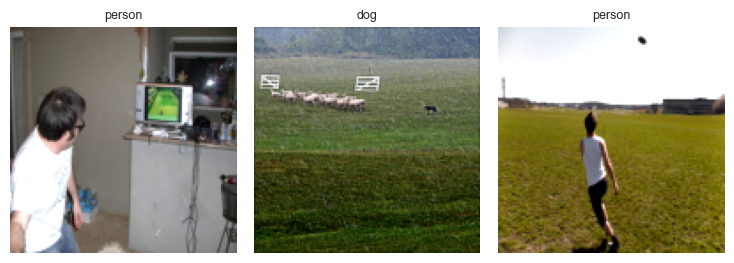

In [9]:
def show_samples(ds, n=3):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    _, axes = plt.subplots(1, n, figsize=(n*2.5, 2.8))
    for ax, idx in zip(axes, random.sample(range(len(ds)), n)):
        img_t, label = ds[idx]
        ax.imshow((img_t * std + mean).clamp(0,1).permute(1,2,0).numpy())
        ax.set_title(CLS_NAMES[label], fontsize=9)
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_samples(train_ds)

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        if pool: layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class COCOCNN(nn.Module):
    def __init__(self, num_cls=5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(  3,  64),
            ConvBlock( 64, 128),
            ConvBlock(128, 256),
            ConvBlock(256, 256),
            ConvBlock(256, 512, pool=False),
            ConvBlock(512, 512, pool=False),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, num_cls),
        )
    def forward(self, x): return self.head(self.pool(self.features(x)))


assert COCOCNN(NUM_CLS)(torch.randn(2, 3, IMG_SZ, IMG_SZ)).shape == (2, NUM_CLS)
count_parameters(COCOCNN(NUM_CLS))

Total params      : 4,635,205
Trainable params  : 4,635,205
Frozen params     : 0


{'total': 4635205, 'trainable': 4635205, 'non_trainable': 0}

In [11]:
def make_loaders(train_ds, val_ds):
    kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0))
    return (
        DataLoader(train_ds, BATCH_SZ, shuffle=True,  **kw),
        DataLoader(val_ds,   BATCH_SZ, shuffle=False, **kw),
    )

def subset_balanced(ds, frac):
    rng, buckets = random.Random(SEED), defaultdict(list)
    for i, (_, label) in enumerate(ds.samples):
        buckets[label].append(i)
    chosen = []
    for idxs in buckets.values():
        rng.shuffle(idxs)
        chosen.extend(idxs[:max(1, int(len(idxs) * frac))])
    return Subset(ds, chosen)

In [12]:
train_20, val_20       = subset_balanced(train_ds, EXP_FRAC), subset_balanced(val_ds, EXP_FRAC)
train_dl_20, val_dl_20 = make_loaders(train_20, val_20)
print(f"train: {len(train_20):,} | val: {len(val_20):,}")

model_exp = COCOCNN(NUM_CLS).to(DEVICE)
optimizer = torch.optim.Adam(model_exp.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_EXP)

t0 = time.time()
results_exp = train(
    model=model_exp, train_dataloader=train_dl_20, test_dataloader=val_dl_20,
    optimizer=optimizer, loss_fn=nn.CrossEntropyLoss(),
    epochs=EPOCHS_EXP, device=DEVICE, task="multiclass", scheduler=scheduler,
)
print_train_time(t0, time.time(), device=DEVICE)

train: 10,312 | val: 5,011


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1/5 | train_loss: 0.7590 | train_acc: 0.7981 | val_loss: 0.7796 | val_acc: 0.7876 | lr: 1.00e-03
Epoch: 2/5 | train_loss: 0.7204 | train_acc: 0.8009 | val_loss: 0.7169 | val_acc: 0.7876 | lr: 9.05e-04
Epoch: 3/5 | train_loss: 0.7087 | train_acc: 0.8006 | val_loss: 0.7252 | val_acc: 0.7876 | lr: 6.55e-04
Epoch: 4/5 | train_loss: 0.6827 | train_acc: 0.8009 | val_loss: 0.7174 | val_acc: 0.7876 | lr: 3.45e-04
Epoch: 5/5 | train_loss: 0.6717 | train_acc: 0.8012 | val_loss: 0.6935 | val_acc: 0.7876 | lr: 9.55e-05

Train time on mps: 252.427 seconds


252.4271159172058

In [13]:
train_dl, val_dl = make_loaders(train_ds, val_ds)

model     = COCOCNN(NUM_CLS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

t0 = time.time()
results = train(
    model=model, train_dataloader=train_dl, test_dataloader=val_dl,
    optimizer=optimizer, loss_fn=nn.CrossEntropyLoss(),
    epochs=EPOCHS, device=DEVICE, task="multiclass",
    scheduler=scheduler, early_stopping_patience=4,
)
print_train_time(t0, time.time(), device=DEVICE)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1/15 | train_loss: 0.7319 | train_acc: 0.8005 | val_loss: 0.7422 | val_acc: 0.7892 | lr: 1.00e-03
Epoch: 2/15 | train_loss: 0.7035 | train_acc: 0.8006 | val_loss: 0.7422 | val_acc: 0.7892 | lr: 9.89e-04
Epoch: 3/15 | train_loss: 0.6860 | train_acc: 0.8006 | val_loss: 0.6805 | val_acc: 0.7892 | lr: 9.57e-04
Epoch: 4/15 | train_loss: 0.6639 | train_acc: 0.8006 | val_loss: 0.6690 | val_acc: 0.7893 | lr: 9.05e-04
Epoch: 5/15 | train_loss: 0.6437 | train_acc: 0.8011 | val_loss: 0.6809 | val_acc: 0.7895 | lr: 8.35e-04
Epoch: 6/15 | train_loss: 0.6233 | train_acc: 0.8027 | val_loss: 0.6229 | val_acc: 0.7969 | lr: 7.50e-04
Epoch: 7/15 | train_loss: 0.6068 | train_acc: 0.8050 | val_loss: 0.6061 | val_acc: 0.7978 | lr: 6.55e-04
Epoch: 8/15 | train_loss: 0.5890 | train_acc: 0.8062 | val_loss: 0.6080 | val_acc: 0.8016 | lr: 5.52e-04
Epoch: 9/15 | train_loss: 0.5721 | train_acc: 0.8101 | val_loss: 0.5876 | val_acc: 0.8045 | lr: 4.48e-04
Epoch: 10/15 | train_loss: 0.5522 | train_acc: 0.8150 |

2880.1168699264526

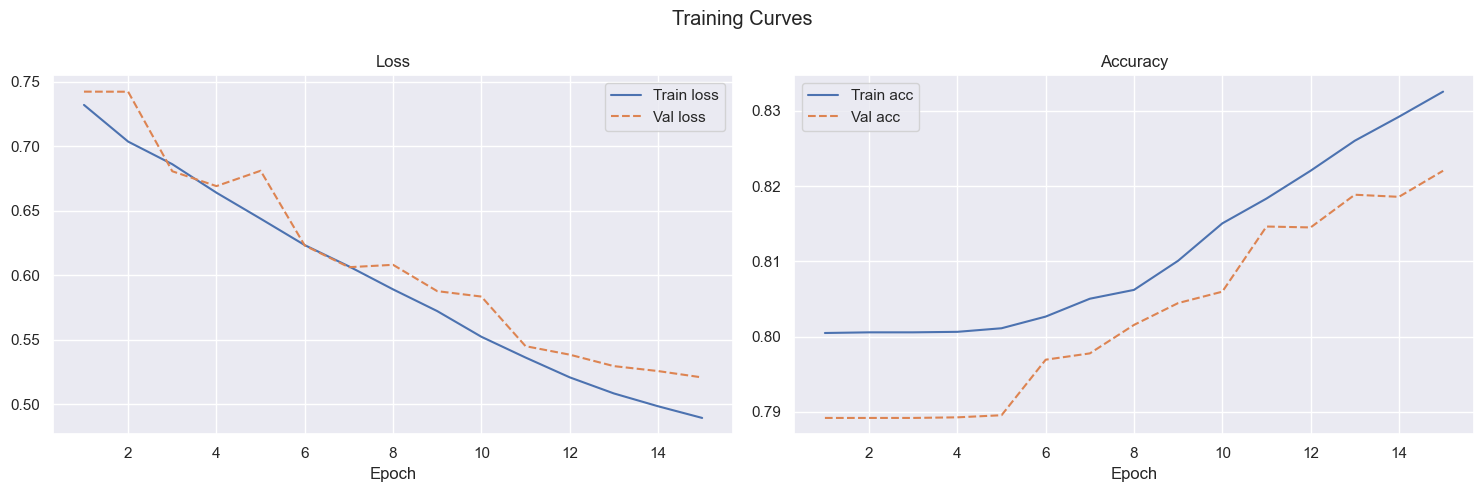

In [14]:
plot_loss_curves(results)

In [15]:
metrics = evaluate(model, val_dl, nn.CrossEntropyLoss(), DEVICE, task="multiclass")
print(f"val loss: {metrics['loss']:.4f} | val acc: {metrics['acc']*100:.1f}%")

val loss: 0.5207 | val acc: 82.2%


In [32]:
all_preds, all_targets = get_all_predictions(model, val_dl, DEVICE, task="multiclass")
confusion_matrix(all_preds, all_targets, class_names=CLS_NAMES)

        person      car      dog      cat  bicycle
person    19129      425       45      187        0
   car     1690      725        3       15        0
   dog      789        8       83      246        0
   cat      660        3       24      671        0
bicycle      348       13        0        2        0


tensor([[19129,   425,    45,   187,     0],
        [ 1690,   725,     3,    15,     0],
        [  789,     8,    83,   246,     0],
        [  660,     3,    24,   671,     0],
        [  348,    13,     0,     2,     0]])

In [17]:
save_model(model, target_dir="models", model_name="coco_cnn.pth")

[INFO] Model state_dict saved → models/coco_cnn.pth


PosixPath('models/coco_cnn.pth')

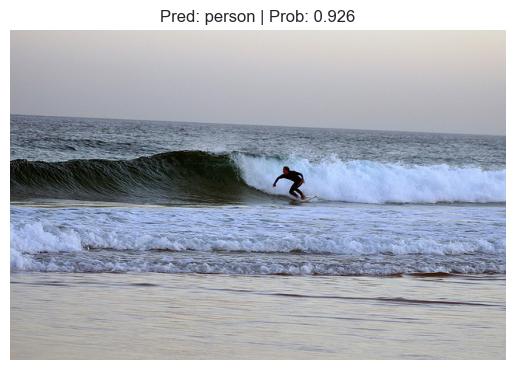

{'class': 'person', 'probability': 0.9257741570472717, 'label_idx': 0}


In [36]:
img_path = COCO_ROOT / "images/test2014" / "COCO_test2014_000000000251.jpg"

print(pred_and_plot_image(model, CLS_NAMES, img_path, image_size=(IMG_SZ, IMG_SZ), device=DEVICE))

Precision: of all the times the model said "that's a person", how often was it right.

Recall: of all the actual persons in the dataset, how many did the model find.

Accuracy: of all images, how many did the model label correctly overall.

F1: a single combined score of precision and recall. High only when both are high.


In [64]:
i = CLS_NAMES.index("person")

TP = ((all_preds == i) & (all_targets == i)).sum().item()
FP = ((all_preds == i) & (all_targets != i)).sum().item()
FN = ((all_preds != i) & (all_targets == i)).sum().item()
TN = ((all_preds != i) & (all_targets != i)).sum().item()

precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)
accuracy  = (TP + TN) / (TP + FP + FN + TN)

print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1        : {f1:.3f}")
print(f"Accuracy  : {accuracy:.3f}")

Precision : 0.846
Recall    : 0.967
F1        : 0.902
Accuracy  : 0.835


In [65]:
print(f"File size: {os.path.getsize('models/coco_cnn.pth') / 1024**2:.2f} MB")

File size: 17.71 MB
